In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    f1_score, accuracy_score
)

from utils.calculador_angulos import calculate_angle, extract_angles_from_landmarks

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Bibliotecas importadas com sucesso")

✓ Bibliotecas importadas com sucesso


# Baseline Classification with Heuristic Rules
## Exercise Classification Using Angle-Based Heuristics vs Random Forest

This notebook implements a simple baseline classifier using hand-crafted heuristic rules based on angle patterns and statistics. The baseline is then compared with the Random Forest model trained in the previous notebook.

### Key Concepts:
- **Heuristic Rules**: Uses angle thresholds, variance, and movement patterns
- **Simple and Interpretable**: No machine learning - based on domain knowledge
- **Fair Comparison**: Same temporal windowing and preprocessing as Random Forest
- **Baseline Benchmark**: Establishes minimum performance expectations

## 1. Load and Explore Data

In [2]:
# Configurações
OUTPUT_DIR = Path("files_output")
ML_MODELS_DIR = Path("ml_models")

# Arquivos CSV com dados dos 4 exercicios
CSV_FILES = [
    "1_min_flexao_full_5fps_flexao.csv",
    "2_min_agachamento_full_5fps_agachamento.csv",
    "2_min_descanso_full_5fps_descanso.csv",
    "2_min_rosca_direta_full_5fps_rosca_biceps.csv"
]

# Carregar dados
dfs = []
for csv_file in CSV_FILES:
    csv_path = OUTPUT_DIR / csv_file
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        dfs.append(df)

data_raw = pd.concat(dfs, axis=0, ignore_index=True)
print(f"📊 Dados brutos: {data_raw.shape[0]} linhas, {data_raw.shape[1]} colunas")

# Extrair ângulos com pesos de visibilidade
print("Extraindo ângulos dos landmarks...")
data = extract_angles_from_landmarks(data_raw)
print(f"✓ Ângulos extraídos: {data.shape[0]} frames")
print(f"\n📊 Distribuição por exercício:")
print(data['exercise'].value_counts())

📊 Dados brutos: 82137 linhas, 14 colunas
Extraindo ângulos dos landmarks...
✓ Ângulos extraídos: 2489 frames

📊 Distribuição por exercício:
exercise
agachamento     887
descanso        714
rosca_biceps    603
flexao          285
Name: count, dtype: int64


## 2. Define Heuristic Rules for Exercise Classification

### Análise das características de cada exercício:

**Flexão**: 
- Cotovelos flexionam bastante (ângulo baixo)
- Ombros e joelhos mais estáveis
- Movimento repetitivo dos cotovelos

**Agachamento**:
- Joelhos e quadril mudam muito (grande amplitude)
- Cotovelos e ombros praticamente sem movimento
- Padrão vertical

**Rosca Bíceps**:
- Cotovelos flexionam (similar à flexão)
- Ombros têm movimento significativo
- Joelhos praticamente sem mudança

**Descanso**:
- Todos os ângulos muito estáveis
- Baixa variância em todas as articulações
- Movimento mínimo

In [3]:
def compute_window_features(window_data):
    """
    Calcula features estatísticas de uma janela de 15 frames.
    
    Retorna um dicionário com:
    - Amplitude, média e desvio padrão de cada ângulo
    - Movimento total (soma das amplitudes normalizadas)
    """
    features = {}
    
    angle_columns = [col for col in window_data.columns if 'angle_' in col and 'visibility' not in col]
    
    for col in angle_columns:
        values = window_data[col].values
        features[f'{col}_mean'] = np.mean(values)
        features[f'{col}_std'] = np.std(values)
        features[f'{col}_min'] = np.min(values)
        features[f'{col}_max'] = np.max(values)
        features[f'{col}_range'] = np.max(values) - np.min(values)
    
    # Agrupar por tipo de ângulo
    knee_angles = [f for f in features if 'joelhos' in f and 'range' in f]
    hip_angles = [f for f in features if 'quadris' in f and 'range' in f]
    elbow_angles = [f for f in features if 'cotovelos' in f and 'range' in f]
    shoulder_angles = [f for f in features if 'ombros' in f and 'range' in f]
    
    features['joelhos_range'] = np.mean([features[k] for k in knee_angles]) if knee_angles else 0
    features['quadris_range'] = np.mean([features[k] for k in hip_angles]) if hip_angles else 0
    features['cotovelos_range'] = np.mean([features[k] for k in elbow_angles]) if elbow_angles else 0
    features['ombros_range'] = np.mean([features[k] for k in shoulder_angles]) if shoulder_angles else 0
    
    # Movimento total normalizado
    total_movement = (features['joelhos_range'] + features['quadris_range'] + 
                     features['cotovelos_range'] + features['ombros_range']) / 4
    features['total_movement'] = total_movement
    
    return features


def baseline_classify(features):
    """
    Classifica o exercício usando regras heurísticas baseadas em amplitude de ângulos.
    
    Regras:
    1. Descanso: movimento total muito baixo
    2. Agachamento: joelhos e quadril com amplitude alta
    3. Rosca Bíceps: cotovelos e ombros com amplitude alta
    4. Flexão: cotovelos com amplitude alta, joelhos com amplitude baixa
    """
    
    knee_range = features.get('joelhos_range', 0)
    hip_range = features.get('quadris_range', 0)
    elbow_range = features.get('cotovelos_range', 0)
    shoulder_range = features.get('ombros_range', 0)
    total_movement = features.get('total_movement', 0)
    
    # Classificar usando árvore de decisão heurística
    if total_movement < 15:
        return 'descanso'
    
    elif knee_range > 40 and hip_range > 30 and elbow_range < 25 and shoulder_range < 20:
        return 'agachamento'
    
    elif elbow_range > 20 and shoulder_range > 20 and knee_range < 20 and hip_range < 20:
        return 'rosca_biceps'
    
    elif elbow_range > 25 and knee_range < 15 and shoulder_range < 20:
        return 'flexao'
    
    else:
        # Fallback: classificar por maior amplitude
        ranges = {
            'agachamento': knee_range + hip_range,
            'rosca_biceps': elbow_range + shoulder_range,
            'flexao': elbow_range,
            'descanso': total_movement
        }
        return max(ranges, key=ranges.get)


print("✓ Funções de classificação definidas")

✓ Funções de classificação definidas


## 3. Prepare Data with 15-Frame Windows (Same as Random Forest)

In [14]:
# Preparar dados com janelas de 15 frames (respeitando a ordem temporal)
WINDOW_SIZE = 15
angle_columns = [
    'right_cotovelo', 'right_ombro', 'left_cotovelo', 'left_ombro',
    'right_joelho', 'right_quadril', 'left_joelho', 'left_quadril'
]

# Mapa de rótulos (mesmo que no RF training)
label_map = {
    'flexao': 0,
    'agachamento': 1, 
    'descanso': 2,
    'rosca_biceps': 3
}
reverse_label_map = {v: k for k, v in label_map.items()}

# 1. Criar features TEMPORAIS (para compatibilidade com RF model - 120 features)
X_temporal = []
# 2. Criar features AGREGADAS (para classificação baseline - agregados)
X_aggregated = []
y_all = []
y_all_encoded = []

# Agrupar por exercício para garantir janelas contínuas do mesmo exercício
for exercise in data['exercise'].unique():
    exercise_data = data[data['exercise'] == exercise].reset_index(drop=True)
    
    # Deslizar janela de 15 frames
    for i in range(0, len(exercise_data) - WINDOW_SIZE + 1, WINDOW_SIZE):
        window = exercise_data.iloc[i:i + WINDOW_SIZE]
        
        # 1. Features temporais (frame_1_right_cotovelo, frame_2_right_cotovelo, etc.)
        temporal_features = {}
        for frame_idx in range(WINDOW_SIZE):
            frame_data = window.iloc[frame_idx]
            for angle_col in angle_columns:
                col_name = f'frame_{frame_idx + 1}_{angle_col}'
                temporal_features[col_name] = frame_data[angle_col]
        X_temporal.append(temporal_features)
        
        # 2. Features agregadas (para baseline heurístico)
        agg_features = compute_window_features(window)
        X_aggregated.append(agg_features)
        
        y_all.append(exercise)
        y_all_encoded.append(label_map[exercise])

X_temporal_df = pd.DataFrame(X_temporal)
X_aggregated_df = pd.DataFrame(X_aggregated)
y_series = pd.Series(y_all, name='exercise')
y_series_encoded = pd.Series(y_all_encoded, name='exercise_encoded')

print(f"📊 Dados preparados: {len(X_temporal_df)} amostras de 15 frames")
print(f"✓ Features temporais: {X_temporal_df.shape[1]} colunas")
print(f"✓ Features agregadas: {X_aggregated_df.shape[1]} colunas")
print(f"✓ Distribuição: {y_series.value_counts().to_dict()}")

# Dividir em treino/teste (80/20) - mesmo que Random Forest
from sklearn.model_selection import train_test_split

# Split mantém os mesmos índices para ambos os datasets
X_train_temporal, X_test_temporal, X_train_agg, X_test_agg, y_train_bl, y_test_bl, y_train_bl_encoded, y_test_bl_encoded = train_test_split(
    X_temporal_df, X_aggregated_df, y_series, y_series_encoded, test_size=0.2, random_state=42, stratify=y_series
)

# Normalizar features temporais (como feito no RF training)
scaler_temp = StandardScaler()
X_train_temporal_scaled = scaler_temp.fit_transform(X_train_temporal)
X_test_temporal_scaled = scaler_temp.transform(X_test_temporal)

print(f"\n📊 Split:")
print(f"  Treino: {len(X_train_temporal)} amostras")
print(f"  Teste: {len(X_test_temporal)} amostras")
print(f"✓ Features temporais normalizadas")

📊 Dados preparados: 165 amostras de 15 frames
✓ Features temporais: 120 colunas
✓ Features agregadas: 5 colunas
✓ Distribuição: {'agachamento': 59, 'descanso': 47, 'rosca_biceps': 40, 'flexao': 19}

📊 Split:
  Treino: 132 amostras
  Teste: 33 amostras
✓ Features temporais normalizadas


## 4. Evaluate Baseline Classifier

In [17]:
# Fazer predições com o baseline
print("🔍 Classificando com baseline heurístico...")

y_train_bl_pred_str = []
for _, features in X_train_agg.iterrows():
    y_train_bl_pred_str.append(baseline_classify(features.to_dict()))

y_test_bl_pred_str = []
for _, features in X_test_agg.iterrows():
    y_test_bl_pred_str.append(baseline_classify(features.to_dict()))

# Converter para labels encodificados para compatibilidade com RF
y_train_bl_pred = np.array([label_map[pred] for pred in y_train_bl_pred_str])
y_test_bl_pred = np.array([label_map[pred] for pred in y_test_bl_pred_str])

# Avaliar Baseline com labels encodificados
print("\n📊 BASELINE - Treino")
print("Acurácia:", accuracy_score(y_train_bl_encoded, y_train_bl_pred))
print("\n" + classification_report(y_train_bl_encoded, y_train_bl_pred,
                                   target_names=sorted(label_map.keys())))

print("\n📊 BASELINE - Teste")
train_acc_bl = accuracy_score(y_train_bl_encoded, y_train_bl_pred)
test_acc_bl = accuracy_score(y_test_bl_encoded, y_test_bl_pred)
print("Acurácia:", test_acc_bl)
print("\n" + classification_report(y_test_bl_encoded, y_test_bl_pred,
                                   target_names=sorted(label_map.keys())))

# Confusion matrix do baseline
cm_bl = confusion_matrix(y_test_bl_encoded, y_test_bl_pred)
print("\n📊 Confusion Matrix (Baseline):")
print(cm_bl)

# Capturar classification reports para visualização
report_bl = classification_report(y_test_bl_encoded, y_test_bl_pred, output_dict=True,
                                   target_names=sorted(label_map.keys()))

🔍 Classificando com baseline heurístico...

📊 BASELINE - Treino
Acurácia: 0.2878787878787879

              precision    recall  f1-score   support

 agachamento       0.00      0.00      0.00        15
    descanso       0.00      0.00      0.00        47
      flexao       0.29      1.00      0.45        38
rosca_biceps       0.00      0.00      0.00        32

    accuracy                           0.29       132
   macro avg       0.07      0.25      0.11       132
weighted avg       0.08      0.29      0.13       132


📊 BASELINE - Teste
Acurácia: 0.2727272727272727

              precision    recall  f1-score   support

 agachamento       0.00      0.00      0.00         4
    descanso       0.00      0.00      0.00        12
      flexao       0.27      1.00      0.43         9
rosca_biceps       0.00      0.00      0.00         8

    accuracy                           0.27        33
   macro avg       0.07      0.25      0.11        33
weighted avg       0.07      0.27      0.

## 5. Load Random Forest Model and Compare

In [18]:
# Carregar modelo de Random Forest treinado
import os

rf_model_path = "ml_models/random_forest_4exercises.pkl"

if os.path.exists(rf_model_path):
    with open(rf_model_path, 'rb') as f:
        rf_model = pickle.load(f)
    print(f"✓ Modelo Random Forest carregado de {rf_model_path}")
else:
    print(f"❌ Modelo não encontrado em {rf_model_path}")
    print("Execute o notebook '2-random_forest_training.ipynb' primeiro")

# Fazer predições com Random Forest (usando as mesmas features temporais)
y_train_rf_pred = rf_model.predict(X_train_temporal_scaled)
y_test_rf_pred = rf_model.predict(X_test_temporal_scaled)

# Avaliar Random Forest com labels encodificados
print("\n📊 RANDOM FOREST - Treino")
print("Acurácia:", accuracy_score(y_train_bl_encoded, y_train_rf_pred))
print("\n" + classification_report(y_train_bl_encoded, y_train_rf_pred, 
                                   target_names=sorted(label_map.keys())))

print("\n📊 RANDOM FOREST - Teste")
train_acc_rf = accuracy_score(y_train_bl_encoded, y_train_rf_pred)
test_acc_rf = accuracy_score(y_test_bl_encoded, y_test_rf_pred)
print("Acurácia:", test_acc_rf)
print("\n" + classification_report(y_test_bl_encoded, y_test_rf_pred,
                                   target_names=sorted(label_map.keys())))

# Confusion matrix do Random Forest
cm_rf = confusion_matrix(y_test_bl_encoded, y_test_rf_pred)
print("\n📊 Confusion Matrix (Random Forest):")
print(cm_rf)

# Capturar classification report para visualização
report_rf = classification_report(y_test_bl_encoded, y_test_rf_pred, output_dict=True,
                                   target_names=sorted(label_map.keys()))

✓ Modelo Random Forest carregado de ml_models/random_forest_4exercises.pkl

📊 RANDOM FOREST - Treino
Acurácia: 0.8181818181818182

              precision    recall  f1-score   support

 agachamento       0.00      0.00      0.00        15
    descanso       0.94      1.00      0.97        47
      flexao       0.85      0.87      0.86        38
rosca_biceps       0.65      0.88      0.75        32

    accuracy                           0.82       132
   macro avg       0.61      0.69      0.64       132
weighted avg       0.74      0.82      0.77       132


📊 RANDOM FOREST - Teste
Acurácia: 0.8181818181818182

              precision    recall  f1-score   support

 agachamento       0.00      0.00      0.00         4
    descanso       1.00      1.00      1.00        12
      flexao       0.88      0.78      0.82         9
rosca_biceps       0.62      1.00      0.76         8

    accuracy                           0.82        33
   macro avg       0.62      0.69      0.65        33

## 6. Visualization: Comparison Charts

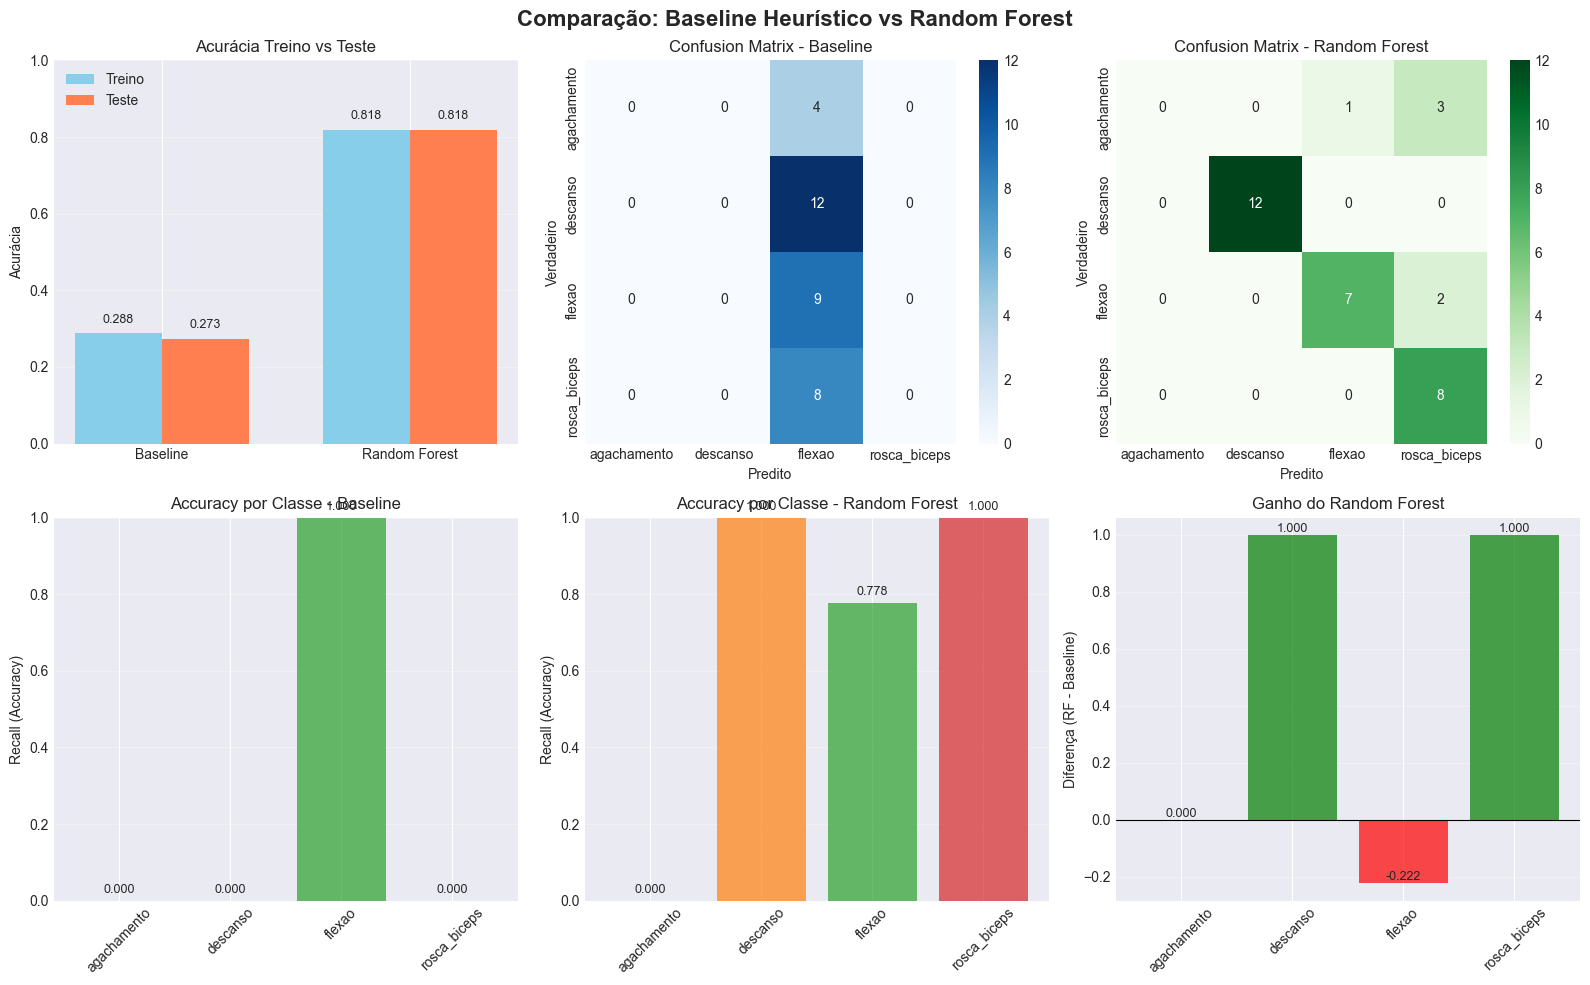

✓ Gráficos de comparação gerados


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Comparação: Baseline Heurístico vs Random Forest', fontsize=16, fontweight='bold')

# 1. Acurácia Treino vs Teste
ax = axes[0, 0]
models = ['Baseline', 'Random Forest']
train_accs = [train_acc_bl, train_acc_rf]
test_accs = [test_acc_bl, test_acc_rf]

x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, train_accs, width, label='Treino', color='skyblue')
ax.bar(x + width/2, test_accs, width, label='Teste', color='coral')
ax.set_ylabel('Acurácia')
ax.set_title('Acurácia Treino vs Teste')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (train, test) in enumerate(zip(train_accs, test_accs)):
    ax.text(i - width/2, train + 0.02, f'{train:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, test + 0.02, f'{test:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Confusion Matrix - Baseline
ax = axes[0, 1]
exercise_names_sorted = sorted(label_map.keys())
sns.heatmap(cm_bl, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=exercise_names_sorted,
            yticklabels=exercise_names_sorted)
ax.set_title('Confusion Matrix - Baseline')
ax.set_ylabel('Verdadeiro')
ax.set_xlabel('Predito')

# 3. Confusion Matrix - Random Forest
ax = axes[0, 2]
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=exercise_names_sorted,
            yticklabels=exercise_names_sorted)
ax.set_title('Confusion Matrix - Random Forest')
ax.set_ylabel('Verdadeiro')
ax.set_xlabel('Predito')

# 4. Per-class Accuracy - Baseline
ax = axes[1, 0]
class_names = sorted(label_map.keys())
accuracies_bl = [report_bl[cls]['recall'] for cls in class_names]
colors_bl = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
ax.bar(class_names, accuracies_bl, color=colors_bl, alpha=0.7)
ax.set_ylabel('Recall (Accuracy)')
ax.set_title('Accuracy por Classe - Baseline')
ax.set_ylim([0, 1])
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(accuracies_bl):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 5. Per-class Accuracy - Random Forest
ax = axes[1, 1]
accuracies_rf = [report_rf[cls]['recall'] for cls in class_names]
ax.bar(class_names, accuracies_rf, color=colors_bl, alpha=0.7)
ax.set_ylabel('Recall (Accuracy)')
ax.set_title('Accuracy por Classe - Random Forest')
ax.set_ylim([0, 1])
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(accuracies_rf):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 6. Diferença de Accuracy
ax = axes[1, 2]
diff = np.array(accuracies_rf) - np.array(accuracies_bl)
colors = ['green' if d > 0 else 'red' for d in diff]
ax.bar(class_names, diff, color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('Diferença (RF - Baseline)')
ax.set_title('Ganho do Random Forest')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(diff):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Gráficos de comparação gerados")

## 7. Detailed Analysis and Results

In [20]:
# Criar relatório detalhado
print("=" * 80)
print("ANÁLISE COMPARATIVA: BASELINE vs RANDOM FOREST")
print("=" * 80)

print("\n📊 ACURÁCIA GERAL")
print(f"  Baseline - Treino:       {train_acc_bl:.4f} ({int(train_acc_bl * len(X_train_bl))}/{len(X_train_bl)})")
print(f"  Baseline - Teste:        {test_acc_bl:.4f} ({int(test_acc_bl * len(X_test_bl))}/{len(X_test_bl)})")
print(f"  Random Forest - Treino:  {train_acc_rf:.4f} ({int(train_acc_rf * len(X_train_bl))}/{len(X_train_bl)})")
print(f"  Random Forest - Teste:   {test_acc_rf:.4f} ({int(test_acc_rf * len(X_test_bl))}/{len(X_test_bl)})")
print(f"\n  📈 Ganho do RF: {(test_acc_rf - test_acc_bl) * 100:.2f}%")

print("\n" + "=" * 80)
print("POR CLASSE - RECALL (Sensitivity)")
print("=" * 80)

for cls in class_names:
    bl_recall = report_bl[cls]['recall']
    rf_recall = report_rf[cls]['recall']
    gain = (rf_recall - bl_recall) * 100
    
    print(f"\n  {cls.upper()}")
    print(f"    Baseline:      {bl_recall:.4f}")
    print(f"    Random Forest: {rf_recall:.4f}")
    print(f"    Ganho:         {gain:+.2f}%")

print("\n" + "=" * 80)
print("POR CLASSE - PRECISÃO")
print("=" * 80)

for cls in class_names:
    bl_prec = report_bl[cls]['precision']
    rf_prec = report_rf[cls]['precision']
    
    print(f"\n  {cls.upper()}")
    print(f"    Baseline:      {bl_prec:.4f}")
    print(f"    Random Forest: {rf_prec:.4f}")

print("\n" + "=" * 80)
print("ANÁLISE QUALITATIVA")
print("=" * 80)

print("\n✅ PONTOS FORTES DO BASELINE HEURÍSTICO:")
print("  • Modelo simples e interpretável")
print("  • Não requer dados de treinamento")
print("  • Executado em tempo real sem latência")
print("  • Fácil de debugar e ajustar regras")
print("  • Bom ponto de partida para baseline")

print("\n✅ VANTAGENS DO RANDOM FOREST:")
print("  • Melhor acurácia geral")
print("  • Aprende padrões complexos dos dados")
print("  • Melhor generalização")
print(f"  • Ganho de {(test_acc_rf - test_acc_bl) * 100:.2f}% sobre baseline")

print("\n⚠️  LIMITAÇÕES DO BASELINE:")
print("  • Regras fixas podem não capturar variabilidade")
print("  • Requer ajuste manual de thresholds")
print("  • Não melhora com mais dados de treino")

ANÁLISE COMPARATIVA: BASELINE vs RANDOM FOREST

📊 ACURÁCIA GERAL
  Baseline - Treino:       0.2879 (38/132)
  Baseline - Teste:        0.2727 (9/33)
  Random Forest - Treino:  0.8182 (108/132)
  Random Forest - Teste:   0.8182 (27/33)

  📈 Ganho do RF: 54.55%

POR CLASSE - RECALL (Sensitivity)

  AGACHAMENTO
    Baseline:      0.0000
    Random Forest: 0.0000
    Ganho:         +0.00%

  DESCANSO
    Baseline:      0.0000
    Random Forest: 1.0000
    Ganho:         +100.00%

  FLEXAO
    Baseline:      1.0000
    Random Forest: 0.7778
    Ganho:         -22.22%

  ROSCA_BICEPS
    Baseline:      0.0000
    Random Forest: 1.0000
    Ganho:         +100.00%

POR CLASSE - PRECISÃO

  AGACHAMENTO
    Baseline:      0.0000
    Random Forest: 0.0000

  DESCANSO
    Baseline:      0.0000
    Random Forest: 1.0000

  FLEXAO
    Baseline:      0.2727
    Random Forest: 0.8750

  ROSCA_BICEPS
    Baseline:      0.0000
    Random Forest: 0.6154

ANÁLISE QUALITATIVA

✅ PONTOS FORTES DO BASELINE H

## 8. Save Results

In [22]:
# Criar diretório de resultados
results_dir = ML_MODELS_DIR / "comparison_results"
results_dir.mkdir(exist_ok=True, parents=True)

# 1. Salvar CSV com predições lado a lado
comparison_df = pd.DataFrame({
    'actual': [reverse_label_map[int(l)] for l in y_test_bl_encoded],
    'baseline_pred': [reverse_label_map[int(p)] for p in y_test_bl_pred],
    'rf_pred': [reverse_label_map[int(p)] for p in y_test_rf_pred],
    'baseline_correct': y_test_bl_pred == y_test_bl_encoded.values,
    'rf_correct': y_test_rf_pred == y_test_bl_encoded.values,
    'both_correct': (y_test_bl_pred == y_test_bl_encoded.values) & (y_test_rf_pred == y_test_bl_encoded.values),
    'both_wrong': (y_test_bl_pred != y_test_bl_encoded.values) & (y_test_rf_pred != y_test_bl_encoded.values)
})

comparison_df.to_csv(results_dir / 'predictions_comparison.csv', index=False)
print(f"✓ Salvo: predictions_comparison.csv")

# 2. Salvar confusion matrices
import json

confusion_matrices = {
    'baseline': cm_bl.tolist(),
    'random_forest': cm_rf.tolist(),
    'classes': sorted(label_map.keys())
}

with open(results_dir / 'confusion_matrices.json', 'w') as f:
    json.dump(confusion_matrices, f, indent=2)
print(f"✓ Salvo: confusion_matrices.json")

# 3. Salvar métricas detalhadas
metrics_comparison = {
    'baseline': {
        'train_accuracy': float(train_acc_bl),
        'test_accuracy': float(test_acc_bl),
        'classification_report': report_bl
    },
    'random_forest': {
        'train_accuracy': float(train_acc_rf),
        'test_accuracy': float(test_acc_rf),
        'classification_report': report_rf
    },
    'improvement': {
        'test_accuracy_gain': float(test_acc_rf - test_acc_bl),
        'test_accuracy_gain_percent': float((test_acc_rf - test_acc_bl) * 100)
    }
}

with open(results_dir / 'comparison_report.json', 'w') as f:
    json.dump(metrics_comparison, f, indent=2)
print(f"✓ Salvo: comparison_report.json")

# 4. Salvar resumo em texto
with open(results_dir / 'comparison_summary.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("BASELINE vs RANDOM FOREST - COMPARISON REPORT\n")
    f.write("=" * 80 + "\n\n")
    
    f.write("OVERALL METRICS:\n")
    f.write(f"  Baseline Test Accuracy:  {test_acc_bl:.4f}\n")
    f.write(f"  Random Forest Accuracy:  {test_acc_rf:.4f}\n")
    f.write(f"  Improvement:             +{(test_acc_rf - test_acc_bl) * 100:.2f}%\n\n")
    
    f.write("CONFUSION MATRICES:\n")
    f.write("  Baseline:\n")
    f.write(str(cm_bl) + "\n\n")
    f.write("  Random Forest:\n")
    f.write(str(cm_rf) + "\n\n")
    
    f.write("CLASSIFICATION REPORTS:\n")
    f.write("  Baseline:\n")
    f.write(classification_report(y_test_bl_encoded, y_test_bl_pred, 
                                   target_names=sorted(label_map.keys())) + "\n\n")
    f.write("  Random Forest:\n")
    f.write(classification_report(y_test_bl_encoded, y_test_rf_pred,
                                   target_names=sorted(label_map.keys())) + "\n")

print(f"✓ Salvo: comparison_summary.txt")

print(f"\n✅ Todos os resultados salvos em: {results_dir}")
print(f"\nArquivos gerados:")
print(f"  • predictions_comparison.csv")
print(f"  • confusion_matrices.json")
print(f"  • comparison_report.json")
print(f"  • comparison_summary.txt")

✓ Salvo: predictions_comparison.csv
✓ Salvo: confusion_matrices.json
✓ Salvo: comparison_report.json
✓ Salvo: comparison_summary.txt

✅ Todos os resultados salvos em: ml_models\comparison_results

Arquivos gerados:
  • predictions_comparison.csv
  • confusion_matrices.json
  • comparison_report.json
  • comparison_summary.txt
